# Phase 1 main experiment (part 1d): is the importance-disagreement real, or an artifact?

**Why this notebook exists.** F007's most intellectually valuable finding is that
SHAP-importance and permutation-importance of the *same* oracle agree at
near-chance (GT2/GT3 Jaccard 0.11-0.20, chance ~0.10), which would make the
localization target ill-defined. Before that becomes a headline thesis
contribution, it has to survive two challenges it has not yet faced:

1. **Is it permutation noise?** Permutation importance is a known-unstable
   estimator under feature correlation, and CICIDS flow features are heavily
   correlated. The GT2/GT3 gap might be permutation variance, not a genuine
   disagreement between what SHAP and permutation "believe" matters.
2. **Is it RandomForest-specific?** Everything so far is RF + TreeSHAP. If the
   disagreement vanishes on a different model class, it is a property of
   RandomForest, not of explanation-based drift localization.

**How we test it.** We compute three *independent* importance estimators on each
post-drift day -- TreeSHAP (attribution), permutation importance with 20 repeats
(ablation), and the model's built-in gain importance (split-based) -- for two
model classes (the RandomForest oracle and a freshly-trained XGBoost oracle).
For each we measure **self-stability** (does a method agree with itself across
seeds?) and **cross-method disagreement** (do different methods pick the same
top-15?).

The decisive pair is **SHAP vs gain**: neither is permutation, so if they
disagree near-chance the effect is not a permutation artifact. The decisive
model comparison is **RF vs XGBoost**: if it replicates, the disagreement is a
property of the problem, not the model.

**What 'fail' means.** If the pillar fails, the thesis does not die -- the
disagreement mechanism is demoted from headline to footnote, and the
framework/conditions thesis leans on the redundancy findings that already stand
(KS >= SHAP on GT2; dual adds nothing across budgets). This gate decides whether
the mechanism is a centrepiece or a caveat.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import shap_importance, topk_indices, jaccard

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
CHECKPOINTS = ROOT / 'experiments' / 'checkpoints'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07d_disagreement.json'
for p in (FIGURES, TABLES, CHECKPOINTS):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)

rf_oracle = joblib.load(meta06['models']['oracle'])
print(f'Loaded RandomForest oracle. {N_FEATURES} features.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'RandomForest': '#0072B2', 'XGBoost': '#D55E00'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07d_disagreement_stability'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Mounted at /content/drive
Loaded RandomForest oracle. 82 features.
Setup complete.


## 2. D020 -- the disagreement-stability test and its pre-registered gate

In [2]:
log_decision(
    decision_id='D020',
    decision=(
        'Before treating the importance-method disagreement (F007) as a headline '
        'contribution, test whether it is (a) genuine rather than permutation '
        'noise, and (b) general rather than RandomForest-specific. Compute three '
        'independent importance estimators -- TreeSHAP, permutation importance '
        '(20 repeats), and built-in gain -- per post-drift day, over 5 seeds, for '
        'two model classes (RF oracle and a fresh XGBoost oracle). Measure '
        'self-stability (top-15 Jaccard of a method with itself across seeds) and '
        'cross-method disagreement (top-15 Jaccard between methods). '
        'Pre-registered gate, committed before execution: the disagreement '
        'mechanism SURVIVES iff (1) SHAP is self-stable (self-Jaccard >= 0.50); '
        '(2) the SHAP-vs-gain pair -- neither is permutation -- disagrees at '
        'Jaccard <= 0.35 post-drift (rules out permutation noise); (3) at least '
        'two of the three method pairs disagree at <= 0.35; and (4) it replicates '
        'on XGBoost (SHAP-vs-gain <= 0.35). If SHAP and gain instead AGREE '
        '(> 0.35), the F007 disagreement was permutation-driven and the pillar is '
        'demoted. If it holds on RF but not XGBoost, it is RF-specific and '
        'narrowed. Chance Jaccard for 15-of-82 sets ~ 0.10.'
    ),
    rationale=(
        'Permutation importance is unstable under feature correlation, and CICIDS '
        'flow features are correlated, so the GT2/GT3 gap could be estimator '
        'noise. And a single model class cannot support a general claim. The '
        'SHAP-vs-gain pair isolates genuine disagreement from permutation noise; '
        'the XGBoost replication isolates a problem property from an RF property. '
        'Failing this gate demotes the mechanism but leaves the redundancy '
        'findings (F005-F007) intact.'
    ),
    alternatives=(
        'Keep n_repeats=5 (rejected: too noisy to judge permutation stability). '
        'Judge on SHAP-vs-permutation only (rejected: cannot separate genuine '
        'disagreement from permutation noise without a third, non-permutation '
        'estimator).'
    ),
)


[DECISION LOGGED] D020


## 3. Configuration

In [3]:
set_global_seed(42)

DAYS = ['tuesday', 'wednesday', 'thursday', 'friday']
CONTROL_DAY = 'tuesday'
POST_DRIFT_DAYS = ['wednesday', 'thursday', 'friday']

GT_SIZE = 15
TOPK = GT_SIZE
SHAP_SAMPLE = 2000
AUX_TRAIN_FRAC = 0.6          # eval split matches nb07/07c
PERM_REPEATS = 20
SEEDS = [42, 1, 7, 13, 23]    # 5 seeds for a stability estimate
XGB_TRAIN_CAP = 300000        # stratified all-days sample for the XGBoost oracle

METHODS = ['shap', 'perm', 'gain']
PAIRS = [('shap', 'perm'), ('shap', 'gain'), ('perm', 'gain')]

# Pre-registered thresholds (see D020):
DISAGREE_MAX = 0.35
SELF_MIN = 0.50

CHANCE_J = (GT_SIZE**2 / N_FEATURES) / (2*GT_SIZE - GT_SIZE**2 / N_FEATURES)
print(f'Chance Jaccard (15 of {N_FEATURES}) ~ {CHANCE_J:.3f}')
print(f'Gate: SHAP self >= {SELF_MIN}; SHAP-vs-gain <= {DISAGREE_MAX}; >=2 pairs <= {DISAGREE_MAX}; replicate on XGB.')
print(f'Seeds: {SEEDS}  |  perm repeats: {PERM_REPEATS}')


Chance Jaccard (15 of 82) ~ 0.101
Gate: SHAP self >= 0.5; SHAP-vs-gain <= 0.35; >=2 pairs <= 0.35; replicate on XGB.
Seeds: [42, 1, 7, 13, 23]  |  perm repeats: 20


## 4. Helpers and the XGBoost oracle

The XGBoost oracle is trained on a stratified all-days sample, mirroring the
privileged RandomForest oracle (which also sees the full week). Both must be
competent detectors for their importances to mean anything; we check recall.


In [4]:
def stratified_sample(X, y, n, seed):
    n = min(n, len(y))
    if y.nunique() < 2 or n >= len(y):
        idx = np.random.default_rng(seed).choice(len(y), size=n, replace=False)
        return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)
    idx, _ = train_test_split(np.arange(len(y)), train_size=n, stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def load_day(day):
    X, y, meta = load_cicids2017(day=day)
    X = X.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
    return X, y, meta


def gain_importance(model):
    """Built-in split-based importance: RF impurity decrease / XGB gain.
    Model-global (not day-specific); used as an independent non-permutation
    estimator."""
    return np.asarray(model.feature_importances_, dtype=float)


def perm_importance(model, X, y, seed):
    r = permutation_importance(model, X, y, scoring='recall',
                               n_repeats=PERM_REPEATS, random_state=seed, n_jobs=-1)
    return r.importances_mean


# ----- train (or load) the XGBoost oracle -----
xgb_ckpt = CHECKPOINTS / 'xgb_oracle.joblib'
if xgb_ckpt.exists():
    xgb_oracle = joblib.load(xgb_ckpt)
    print('Loaded cached XGBoost oracle.')
else:
    print('Training XGBoost oracle on a stratified all-days sample...')
    Xparts, yparts = [], []
    for day in ['monday'] + DAYS:
        Xd, yd, _ = load_day(day)
        Xparts.append(Xd); yparts.append(yd)
    Xall = pd.concat(Xparts, ignore_index=True)
    yall = pd.concat(yparts, ignore_index=True)
    Xtr, ytr = stratified_sample(Xall, yall, XGB_TRAIN_CAP, seed=42)
    xgb_oracle = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        importance_type='gain', eval_metric='logloss',
        n_jobs=-1, random_state=42)
    xgb_oracle.fit(Xtr, ytr)
    joblib.dump(xgb_oracle, xgb_ckpt)
    del Xparts, yparts, Xall, yall, Xtr, ytr
    print('XGBoost oracle trained and cached.')

MODELS = {'RandomForest': rf_oracle, 'XGBoost': xgb_oracle}
print('Models ready:', list(MODELS))


Training XGBoost oracle on a stratified all-days sample...
XGBoost oracle trained and cached.
Models ready: ['RandomForest', 'XGBoost']


## 5. Recall sanity check (both oracles must detect the attacks)

In [5]:
rec_rows = []
for day in POST_DRIFT_DAYS:
    Xd, yd, _ = load_day(day)
    Xs, ys = stratified_sample(Xd, yd, SHAP_SAMPLE, seed=42)
    for mname, model in MODELS.items():
        rec = recall_score(ys, model.predict(Xs), zero_division=0) if ys.nunique() > 1 else float('nan')
        rec_rows.append({'day': day, 'model': mname, 'recall': rec})
rec_df = pd.DataFrame(rec_rows)
print('Oracle recall on post-drift days (should be high for both):')
print(rec_df.pivot(index='day', columns='model', values='recall').round(3).to_string())


Oracle recall on post-drift days (should be high for both):
model      RandomForest  XGBoost
day                             
friday            0.997      1.0
thursday          0.990      1.0
wednesday         0.996      1.0


## 6. Importance loop: top-15 sets per model / day / seed / method

`gain` is model-global, so it is the same across days and seeds for a given
model (its self-stability is 1.0 by construction). `shap` varies with the eval
sample; `perm` varies with the eval sample and the shuffle seed.


In [6]:
tops = {}     # (model, day, seed, method) -> set of top-k indices
gain_top = {}  # (model) -> set  (constant)
t_start = time.time()

for mname, model in MODELS.items():
    gain_top[mname] = set(topk_indices(gain_importance(model), TOPK))

for day in DAYS:
    Xd, yd, _ = load_day(day)
    _, ev_idx = train_test_split(np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
                                 stratify=yd if yd.nunique() > 1 else None, random_state=42)
    Xev = Xd.iloc[ev_idx].reset_index(drop=True)
    yev = yd.iloc[ev_idx].reset_index(drop=True)
    for seed in SEEDS:
        Xs, ys = stratified_sample(Xev, yev, SHAP_SAMPLE, seed)
        for mname, model in MODELS.items():
            tops[(mname, day, seed, 'shap')] = set(topk_indices(shap_importance(model, Xs), TOPK))
            tops[(mname, day, seed, 'perm')] = (
                set(topk_indices(perm_importance(model, Xs, ys, seed), TOPK))
                if ys.nunique() > 1 else set())
            tops[(mname, day, seed, 'gain')] = gain_top[mname]
    print(f'{day:<10} done  ({time.time()-t_start:.0f}s elapsed)')
print('Importance computation complete.')


tuesday    done  (300s elapsed)
wednesday  done  (596s elapsed)
thursday   done  (893s elapsed)
friday     done  (1186s elapsed)
Importance computation complete.


## 7. Self-stability and cross-method disagreement

In [7]:
self_rows, cross_rows = [], []
for mname in MODELS:
    for day in DAYS:
        # self-stability: mean pairwise Jaccard of a method with itself across seeds
        for method in METHODS:
            sets = [tops[(mname, day, s, method)] for s in SEEDS]
            pairs = list(itertools.combinations(range(len(SEEDS)), 2))
            sj = np.mean([jaccard(sets[i], sets[j]) for i, j in pairs]) if pairs else 1.0
            self_rows.append({'model': mname, 'day': day, 'method': method,
                              'self_jaccard': float(sj)})
        # cross-method disagreement: mean over seeds of pairwise top-k Jaccard
        for a, b in PAIRS:
            vals = [jaccard(tops[(mname, day, s, a)], tops[(mname, day, s, b)]) for s in SEEDS]
            cross_rows.append({'model': mname, 'day': day, 'pair': f'{a}-{b}',
                               'jaccard': float(np.mean(vals))})

self_df = pd.DataFrame(self_rows)
cross_df = pd.DataFrame(cross_rows)
self_df.to_csv(TABLES / '07d_self_stability.csv', index=False)
cross_df.to_csv(TABLES / '07d_cross_disagreement.csv', index=False)

def post(df, val):
    return df[df['day'].isin(POST_DRIFT_DAYS)].groupby(
        ['model', df.columns[2]])[val].mean().round(3)

print('Self-stability (post-drift mean top-15 Jaccard of a method with itself):')
print(self_df[self_df['day'].isin(POST_DRIFT_DAYS)]
      .pivot_table(index='method', columns='model', values='self_jaccard').round(3).to_string())
print('\nCross-method disagreement (post-drift mean top-15 Jaccard between methods):')
print(cross_df[cross_df['day'].isin(POST_DRIFT_DAYS)]
      .pivot_table(index='pair', columns='model', values='jaccard').round(3).to_string())
print(f'\n(Chance Jaccard ~ {CHANCE_J:.3f}; gate disagreement threshold {DISAGREE_MAX})')


Self-stability (post-drift mean top-15 Jaccard of a method with itself):
model   RandomForest  XGBoost
method                       
gain           1.000    1.000
perm           0.584    0.559
shap           0.921    0.950

Cross-method disagreement (post-drift mean top-15 Jaccard between methods):
model      RandomForest  XGBoost
pair                            
perm-gain         0.147    0.195
shap-gain         0.543    0.247
shap-perm         0.158    0.350

(Chance Jaccard ~ 0.101; gate disagreement threshold 0.35)


## 8. Figures

  saved: 07d_cross_method_disagreement.png / .pdf


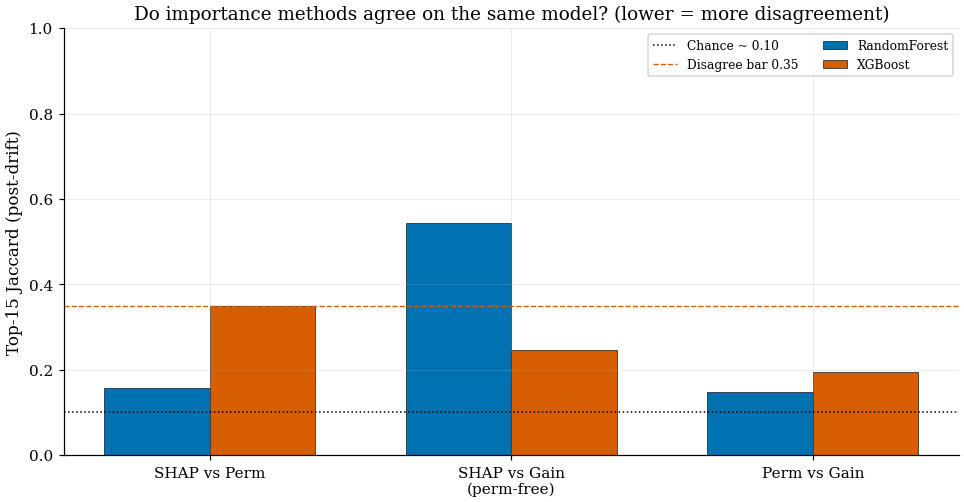

In [8]:
# ----- Figure 1: cross-method disagreement, RF vs XGBoost (the headline) -----
fig, ax = plt.subplots(figsize=(9, 4.8))
pair_names = [f'{a}-{b}' for a, b in PAIRS]
x = np.arange(len(pair_names)); w = 0.35
for i, mname in enumerate(MODELS):
    means = [cross_df[(cross_df['model'] == mname) & (cross_df['pair'] == p)
                      & (cross_df['day'].isin(POST_DRIFT_DAYS))]['jaccard'].mean()
             for p in pair_names]
    ax.bar(x + (i - 0.5) * w, means, w, color=MODEL_COLOR[mname], label=mname,
           edgecolor='black', linewidth=0.4)
ax.axhline(CHANCE_J, ls=':', color='black', lw=1.0, label=f'Chance ~ {CHANCE_J:.2f}')
ax.axhline(DISAGREE_MAX, ls='--', color='#D55E00', lw=0.9, label=f'Disagree bar {DISAGREE_MAX}')
ax.set_xticks(x); ax.set_xticklabels(['SHAP vs Perm', 'SHAP vs Gain\n(perm-free)', 'Perm vs Gain'])
ax.set_ylabel('Top-15 Jaccard (post-drift)'); ax.set_ylim(0, 1.0)
ax.set_title('Do importance methods agree on the same model? (lower = more disagreement)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save_figure(fig, '07d_cross_method_disagreement'); plt.show()


  saved: 07d_self_stability.png / .pdf


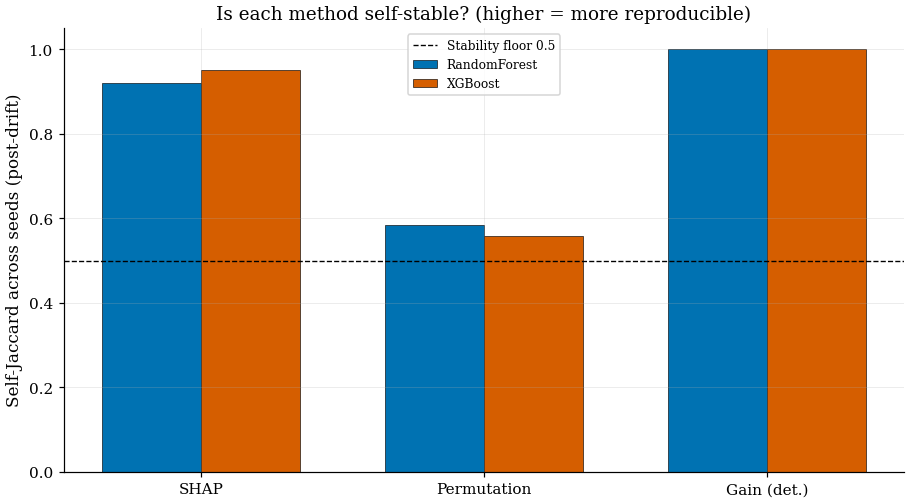

In [9]:
# ----- Figure 2: self-stability per method (is permutation the noisy one?) -----
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(METHODS)); w = 0.35
for i, mname in enumerate(MODELS):
    means = [self_df[(self_df['model'] == mname) & (self_df['method'] == meth)
                     & (self_df['day'].isin(POST_DRIFT_DAYS))]['self_jaccard'].mean()
             for meth in METHODS]
    ax.bar(x + (i - 0.5) * w, means, w, color=MODEL_COLOR[mname], label=mname,
           edgecolor='black', linewidth=0.4)
ax.axhline(SELF_MIN, ls='--', color='black', lw=0.9, label=f'Stability floor {SELF_MIN}')
ax.set_xticks(x); ax.set_xticklabels(['SHAP', 'Permutation', 'Gain (det.)'])
ax.set_ylabel('Self-Jaccard across seeds (post-drift)'); ax.set_ylim(0, 1.05)
ax.set_title('Is each method self-stable? (higher = more reproducible)')
ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, '07d_self_stability'); plt.show()


## 9. Pre-registered verdict (D020)

In [10]:
def cmean(df, model, key, val):
    return float(df[(df['model'] == model) & (df[df.columns[2]] == key)
                    & (df['day'].isin(POST_DRIFT_DAYS))][val].mean())

# RandomForest (primary)
shap_self = cmean(self_df, 'RandomForest', 'shap', 'self_jaccard')
perm_self = cmean(self_df, 'RandomForest', 'perm', 'self_jaccard')
c_sp = cmean(cross_df, 'RandomForest', 'shap-perm', 'jaccard')
c_sg = cmean(cross_df, 'RandomForest', 'shap-gain', 'jaccard')
c_pg = cmean(cross_df, 'RandomForest', 'perm-gain', 'jaccard')
n_disagree = sum(v <= DISAGREE_MAX for v in (c_sp, c_sg, c_pg))

# XGBoost (replication)
c_sg_x = cmean(cross_df, 'XGBoost', 'shap-gain', 'jaccard')
c_sp_x = cmean(cross_df, 'XGBoost', 'shap-perm', 'jaccard')
c_pg_x = cmean(cross_df, 'XGBoost', 'perm-gain', 'jaccard')
n_disagree_x = sum(v <= DISAGREE_MAX for v in (c_sp_x, c_sg_x, c_pg_x))

shap_stable = shap_self >= SELF_MIN
genuine_rf = (c_sg <= DISAGREE_MAX) and shap_stable and (n_disagree >= 2)
replicates = c_sg_x <= DISAGREE_MAX

if genuine_rf and replicates:
    verdict = 'SURVIVES'
elif genuine_rf and not replicates:
    verdict = 'RF-SPECIFIC'
elif (c_sg > DISAGREE_MAX):
    verdict = 'PERMUTATION-DRIVEN'   # the two non-permutation methods agree
else:
    verdict = 'AMBIGUOUS'

print('=' * 66)
print('DISAGREEMENT-STABILITY VERDICT (D020)  -- post-drift means')
print('=' * 66)
print('RandomForest:')
print(f'  self-stability   SHAP={shap_self:.3f}  perm={perm_self:.3f}  (floor {SELF_MIN})')
print(f'  cross-method     SHAP-perm={c_sp:.3f}  SHAP-gain={c_sg:.3f}  perm-gain={c_pg:.3f}')
print(f'  pairs disagreeing (<= {DISAGREE_MAX}): {n_disagree}/3   (chance ~ {CHANCE_J:.2f})')
print('XGBoost (replication):')
print(f'  cross-method     SHAP-perm={c_sp_x:.3f}  SHAP-gain={c_sg_x:.3f}  perm-gain={c_pg_x:.3f}')
print(f'  pairs disagreeing (<= {DISAGREE_MAX}): {n_disagree_x}/3')
print('-' * 66)
print(f'  SHAP self-stable      : {shap_stable}')
print(f'  genuine on RF         : {genuine_rf}  (SHAP-vs-gain <= {DISAGREE_MAX}, perm-free)')
print(f'  replicates on XGBoost : {replicates}')
print(f'\n--> VERDICT: {verdict}')
msg = {
    'SURVIVES': 'Genuine cross-method disagreement, not permutation noise, and model-general. Mechanism is a headline contribution.',
    'RF-SPECIFIC': 'Real on RandomForest but not XGBoost. Narrow the claim to RF; demote from general headline.',
    'PERMUTATION-DRIVEN': 'SHAP and gain AGREE; the F007 disagreement was driven by permutation-importance noise. Demote the mechanism; lean on the redundancy findings.',
    'AMBIGUOUS': 'Mixed signal (e.g. SHAP not self-stable). Treat conservatively as not-confirmed; demote pending more evidence.',
}[verdict]
print('   ' + msg)


DISAGREEMENT-STABILITY VERDICT (D020)  -- post-drift means
RandomForest:
  self-stability   SHAP=0.921  perm=0.584  (floor 0.5)
  cross-method     SHAP-perm=0.158  SHAP-gain=0.543  perm-gain=0.147
  pairs disagreeing (<= 0.35): 2/3   (chance ~ 0.10)
XGBoost (replication):
  cross-method     SHAP-perm=0.350  SHAP-gain=0.247  perm-gain=0.195
  pairs disagreeing (<= 0.35): 2/3
------------------------------------------------------------------
  SHAP self-stable      : True
  genuine on RF         : False  (SHAP-vs-gain <= 0.35, perm-free)
  replicates on XGBoost : True

--> VERDICT: PERMUTATION-DRIVEN
   SHAP and gain AGREE; the F007 disagreement was driven by permutation-importance noise. Demote the mechanism; lean on the redundancy findings.


## 10. Record to the project log

In [11]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'perm_repeats': PERM_REPEATS, 'topk': TOPK,
    'chance_jaccard': CHANCE_J, 'disagree_max': DISAGREE_MAX, 'self_min': SELF_MIN,
    'rf': {'shap_self': shap_self, 'perm_self': perm_self,
           'shap_perm': c_sp, 'shap_gain': c_sg, 'perm_gain': c_pg},
    'xgb': {'shap_perm': c_sp_x, 'shap_gain': c_sg_x, 'perm_gain': c_pg_x},
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F008',
    title='Stability and cross-model generality of importance disagreement (notebook 07d)',
    context='03_phase1_cicids/07d_disagreement_stability',
    what_we_did=(
        'Tested whether the F007 importance-method disagreement is genuine '
        '(vs permutation noise) and general (vs RandomForest-specific), using '
        'three independent estimators (TreeSHAP, permutation with 20 repeats, '
        'built-in gain) over 5 seeds on the RF oracle and a fresh XGBoost oracle. '
        'Measured self-stability and cross-method top-15 Jaccard. Pre-registered '
        'gate (D020): the perm-free SHAP-vs-gain pair decides genuineness; XGBoost '
        'decides generality.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. RandomForest post-drift: SHAP self-stability='
        f'{shap_self:.3f}, perm self-stability={perm_self:.3f}; cross-method '
        f'SHAP-perm={c_sp:.3f}, SHAP-gain={c_sg:.3f}, perm-gain={c_pg:.3f} '
        f'(chance ~{CHANCE_J:.2f}). XGBoost: SHAP-perm={c_sp_x:.3f}, '
        f'SHAP-gain={c_sg_x:.3f}, perm-gain={c_pg_x:.3f}.'
    ),
    why_it_matters=(
        'Decides whether the importance-disagreement mechanism is a headline '
        'thesis contribution or a footnote. SURVIVES -> build the framework on it; '
        'PERMUTATION-DRIVEN or RF-SPECIFIC -> demote and lean on the redundancy '
        'findings (F005-F007), which stand independently.'
    ),
)
print('F008 logged. Record the call on the mechanism in a hand journal entry.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07d_disagreement.json
[FINDING LOGGED] F008: Stability and cross-model generality of importance disagreement (notebook 07d)
F008 logged. Record the call on the mechanism in a hand journal entry.


## 11. What this settles

- **SURVIVES** -> the disagreement is genuine (two non-permutation estimators
  disagree near-chance), self-stable, and replicates on XGBoost. The mechanism
  -- "the localization target is ill-defined because importance methods disagree"
  -- becomes the intellectual centrepiece of the framework thesis. Proceed to
  build breadth (UNSW + the second model class already in hand) around it.
- **RF-SPECIFIC** -> real on RandomForest, gone on XGBoost. Keep it as a
  model-specific observation, not a general law; the headline shifts to the
  redundancy benchmark, with the disagreement as a RandomForest case study.
- **PERMUTATION-DRIVEN** -> SHAP and gain agree, so the F007 gap was
  permutation-importance noise under feature correlation. Demote the mechanism;
  the thesis stands on the redundancy findings (KS >= SHAP on GT2, dual adds
  nothing across budgets) plus the evaluation framework, with an honest note
  that the apparent disagreement was an estimator artifact.
- **AMBIGUOUS** -> treat as not-confirmed and gather more evidence before relying
  on it.

In every branch the redundancy findings survive, so the thesis is not at risk --
only the prominence of the disagreement mechanism is.

Record the decision by hand:

```python
add_journal_entry(
    title='Notebook 07d disagreement-stability verdict and the call on the mechanism',
    body='...the RF and XGBoost numbers, the verdict, and whether the mechanism is headline or footnote...',
)
```
